# Self-Collaboration over NL2RepoBench: what the round loop scored, and what it consumed

Job `2026-09-05__16-27-27` is 104 trials — every task in the benchmark, once each, one
model, and three roles played by that one model in turn. An **Analyst** reads the
specification and lists the files to write. A **Coder** writes them, with a budget of 15
tool-using steps. A **Tester** runs the project's own test command and, if it fails,
hands the report back to the Coder for another round, up to 3 rounds.

That shape gives this arm something neither of the others has: an opinion of its own
about whether it succeeded, formed before the hidden tests ever run. Much of what
follows is about how good that opinion turns out to be.

This notebook reads the job directory as it stands on disk and asks:

1. **What did it score?** — the reward distribution, and how it moves with difficulty.
2. **What did the loop actually do?** — rounds spent, steps spent, and whether the
   method's own tester ever passed.
3. **What did the tokens buy?** — tokens per trial against reward earned.
4. **How did the zeros happen?** — a zero from failing tests and a zero from an
   unimportable package are different findings, and the verifier logs tell them apart.

Nothing here is re-run or re-scored; every number is read from the files the job wrote.
This is one of three run notebooks that share a reader and a set of figures, and it
makes **no comparison between the arms** — that is a separate exercise once every arm
has been run.

## 1. Parameters

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# --- what to read ------------------------------------------------------------
JOB = "2026-09-05__16-27-27"

# Reward at or above which a task counts as solved rather than partially credited.
# Not 1.0: a run that passes 95% of a package's hidden tests has produced a working
# package, and calling that a failure would flatter every method equally. Every
# other threshold this notebook uses is a budget, and those are read from each
# trial's own configuration rather than restated here.
SOLVED_AT = 0.9

# Figures are prefixed so the arms' figures sit beside each other in docs/figures
# without overwriting one another.
FIGURE_PREFIX = "selfcollab"

# `job_analysis` and `job_figures` live beside the notebooks. Jupyter puts the
# notebook's own directory on the path; this covers a kernel started elsewhere.
NOTEBOOKS = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

import matplotlib.pyplot as plt

import job_analysis as ja
import job_figures as jf

jf.use_house_style()
save = jf.saver(FIGURE_PREFIX)

df = ja.load_job(JOB, solved_at=SOLVED_AT)
print(f"job     : {ja.job_path(JOB)}")
print(f"arm     : {df.attrs['arm'].name}")
print(f"budget  : {df.attrs['arm'].budget_name} = {df.attrs['budget']}")
print(f"solved  : reward >= {SOLVED_AT}")
print()
print(ja.headline(df))
print()
print(df.outcome.value_counts().to_string())

job     : C:\Code\EvaluationPlatform\jobs\2026-09-05__16-27-27
arm     : self-collaboration
budget  : max_rounds = 3
solved  : reward >= 0.9

trials          : 104
mean reward     : 0.531   median 0.628   (n=104)
total tokens    : 184.2M  (80% of input served from cache)
total wall clock: 14.5 h summed over trials

outcome
solved              43
partial credit      36
never imported      15
ran, all failed      5
never configured     3
no verdict           2


## 2. Conventions

Two rules govern every figure, and both live in `job_figures` rather than being
restated per notebook.

**Ordered variables get ordered ramps.** Difficulty, token quartile and failure stage
are all ordered, so each gets one hue running light to dark rather than a set of
arbitrary colours. Where none of them is the subject, grey is context and blue is the
thing being shown; red is reserved for the one thing a figure is warning about.

**Text on a figure is a title, an axis word, and direct labels on the marks.** The
strings for the shared figures are in `jf.FIGURE_TEXT` and every one of them takes a
`text=` override, so re-wording a chart never means touching plotting code. Titles that
quote a number are format strings filled from the data at draw time, so they cannot go
stale when `JOB` changes. The cell below holds the same thing for the figures that only
this notebook draws.

In [2]:
import matplotlib.pyplot as plt

# The figures only this notebook draws. Everything else is `jf.FIGURE_TEXT`.
TEXT = {
    "verdict": dict(
        title="Ein Bestehen ist ein starkes Signal, ein Nichtbestehen nicht",
        x="", y="Reward",
        series={True: "eigene Tests bestanden", False: "eigene Tests nie bestanden"},
        note="Mittel {mean:.2f}\nn={n}",
    ),
    "endings": dict(
        title="{n_unverified} von {n} Läufen enden auf einer ungeprüften Änderung",
        x="Läufe", y="", note="{n}   mittlerer Reward {reward:.2f}",
    ),
}

## 3. Reading the job directory

`ja.load_job` returns one row per trial. Its shared half — reward, tokens,
timings, the pytest summary, and the reason behind every flat zero — is read the same
way for every arm, so a cause counted here means what it means in the other run
notebooks. `ja.COMMON_COLUMNS` is that contract; anything else on the frame is this
arm's own, listed in its `ja.ARMS` entry.

What this arm records on top is the role transcript, counted off the log's own banners:
`rounds`, `coder_rounds`, `tester_rounds`, `analyst_steps`, `coder_steps`,
`coder_rounds_at_cap`, the tool mix (`n_bash`, `n_read`, `n_edit`), and
`self_test_passed` — whether the method's own Tester ever came back green. The budget
here is `max_rounds`, and `hit_budget` means the loop used every round without its own
tester ever passing.

The log is regular enough to read exactly. It writes one
`=== Phase 1: Analyst (Localizer) ===` banner, then alternating
`=== Round n/3: Coder (Patcher) ===` and `=== Round n/3: Tester (Verifier) ===`
banners, with a `[Step k/N][tools]` line per step and either `Tests PASSED!` or
`Tests FAILED. Feeding report back to Coder...` after each Tester round. Counting those
gives the rounds used, the steps spent per role, and the method's own verdict, without
having to parse the model's prose.

## 4. What the run scored

Ranking every trial rather than binning them shows the shape of the distribution
without a choice of bin width doing any of the arguing.

wrote docs\figures\selfcollab-reward-ranked.png


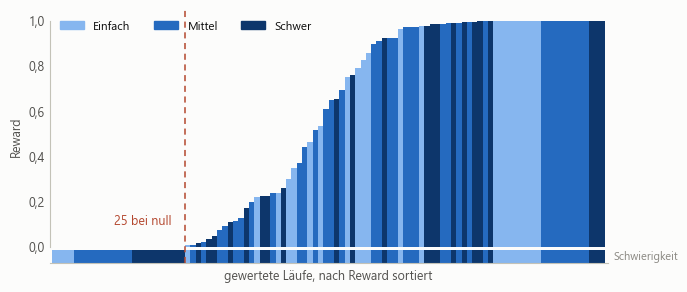

            trials at zero  scored trials  share of the level
difficulty                                                   
Easy                     4             26                0.15
Medium                  11             46                0.24
Hard                    10             32                0.31


In [3]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_ranked(df), "reward-ranked")
plt.show()

print(ja.zero_rate(df).round(2).to_string())

Difficulty is the benchmark's own label, assigned from lines of code before any model
saw the task, so the gradient below is less a finding about this run than a check that
the run behaves the way the label says it should.

wrote docs\figures\selfcollab-reward-by-difficulty.png


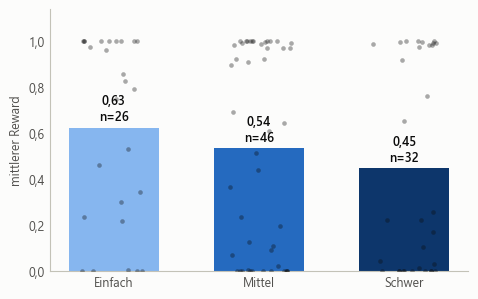

In [4]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_by_difficulty(df), "reward-by-difficulty")
plt.show()

## 5. The loop's own opinion

This arm carries a Tester role, so it forms a verdict on its own work before the hidden
tests are run. The verdict turns out to be **asymmetric**, which is a more useful way to
read it than as a single accuracy figure.

**A pass is strong evidence.** The trials whose own test command passed average far
higher on the hidden tests, and only one of them scored zero.

**A non-pass is weak evidence.** The group that never satisfied its own tester is not a
group of failures — it is bimodal. A large share of it was solved outright anyway, and
another block scored zero, with comparatively little in between. Plotting the trials
themselves rather than their means is the only way to see that, so the figure below
draws every point with the group mean across it.

**And it rarely fires at all.** Only a small minority of trials ever reached a passing
self-test; the rest simply ran out of rounds.

wrote docs\figures\selfcollab-self-test-verdict.png

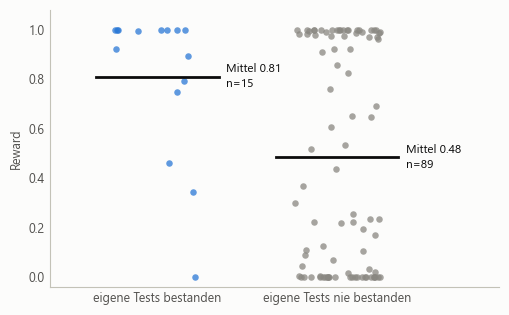

own tests passed      :  15 trials, mean reward 0.811, 9 solved, 1 at zero
own tests never passed:  89 trials, mean reward 0.484, 34 solved, 24 at zero


In [5]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["verdict"]

scored = df[df.scored]
groups = [True, False]
means = [scored.loc[scored.self_test_passed == g, "reward"].mean() for g in groups]
rng = np.random.default_rng(0)   # jitter only

fig, ax = plt.subplots(figsize=(5.8, 3.6))
for i, group in enumerate(groups):
    points = scored.loc[scored.self_test_passed == group, "reward"]
    # Every trial is drawn. A bar of the mean would hide that the right-hand
    # group is bimodal rather than uniformly poor.
    ax.scatter(
        i + rng.uniform(-0.24, 0.24, len(points)), points,
        s=22, color=[jf.SUBJECT, jf.CONTEXT][i], alpha=0.75, linewidth=0, zorder=3,
    )
    ax.plot([i - 0.34, i + 0.34], [means[i]] * 2, color=jf.INK, linewidth=2, zorder=4)
    ax.annotate(
        t["note"].format(mean=means[i], n=len(points)), xy=(i + 0.38, means[i]),
        color=jf.INK, fontsize=8.5, va="center", linespacing=1.4,
    )

jf.title(ax, t["title"])
ax.set_ylabel(t["y"])
ax.set_ylim(-0.04, 1.08)
ax.set_xlim(-0.6, len(groups) - 0.1)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels([t["series"][g] for g in groups])
jf.tidy(ax)
save(fig, "self-test-verdict")
plt.show()

for label, part in (("own tests passed", scored[scored.self_test_passed]),
                    ("own tests never passed", scored[~scored.self_test_passed])):
    print(f"{label:22s}: {len(part):3d} trials, mean reward {part.reward.mean():.3f},"
          f" {int(part.solved.sum())} solved, {int((part.reward == 0).sum())} at zero")

The loop's structure explains why the verdict fires so rarely. The Tester runs *between*
Coder rounds, never after the last one — so a trial that uses all three rounds has its
final edit sent to the external verifier without the method's own gate ever seeing it.
That is not a rare corner: it is what happens to the large majority of trials.

wrote docs\figures\selfcollab-loop-endings.png

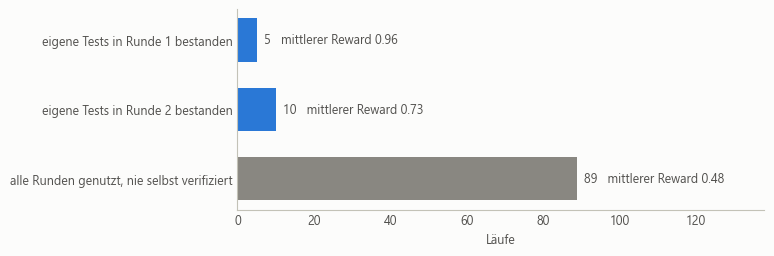

coder rounds run        : 292
  of which used every step: 264 (90%)
  trials with >=1 such round: 104 of 104
tester rounds run       : 203
analyst steps used      : median 7

tool calls over the whole run
  bash      : 5,486
  read_file : 936
  edit_file : 282


In [6]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["endings"]

order = sorted(df.ending.unique(), key=lambda e: ("never" in e, e))
labels = [jf.de(ending) for ending in order]
counts = df.ending.value_counts().reindex(order)
reward = df.groupby("ending").reward.mean().reindex(order)
unverified = int(df.hit_budget.sum())

fig, ax = plt.subplots(figsize=(6.8, 2.6))
bars = ax.barh(
    labels[::-1], counts[order[::-1]], height=0.62, zorder=2,
    color=[jf.CONTEXT if "never" in e else jf.SUBJECT for e in order[::-1]],
)
for rect, ending in zip(bars, order[::-1]):
    ax.annotate(
        t["note"].format(n=counts[ending], reward=reward[ending]),
        xy=(rect.get_width(), rect.get_y() + rect.get_height() / 2),
        xytext=(5, 0), textcoords="offset points", va="center",
        fontsize=9, color=jf.INK_2,
    )

jf.title(ax, t["title"], n_unverified=unverified, n=len(df))
ax.set_xlabel(t["x"])
ax.set_xlim(0, counts.max() * 1.55)
jf.tidy(ax, grid_axis="x")
save(fig, "loop-endings")
plt.show()

coder_cap = df.coder_rounds_at_cap.sum()
print(f"coder rounds run        : {int(df.coder_rounds.sum())}")
print(f"  of which used every step: {int(coder_cap)}"
      f" ({coder_cap / df.coder_rounds.sum():.0%})")
print(f"  trials with >=1 such round: {int((df.coder_rounds_at_cap > 0).sum())} of {len(df)}")
print(f"tester rounds run       : {int(df.tester_rounds.sum())}")
print(f"analyst steps used      : median {df.analyst_steps.median():.0f}")
print()
print("tool calls over the whole run")
for label, column in (("bash", "n_bash"), ("read_file", "n_read"), ("edit_file", "n_edit")):
    print(f"  {label:10s}: {int(df[column].sum()):,}")

## 6. What the tokens bought

Sorting the trials into four equal groups by what they consumed puts the two halves of the
budget question side by side: what each quarter returned, and what each quarter
consumed.

wrote docs\figures\selfcollab-token-quartiles.png


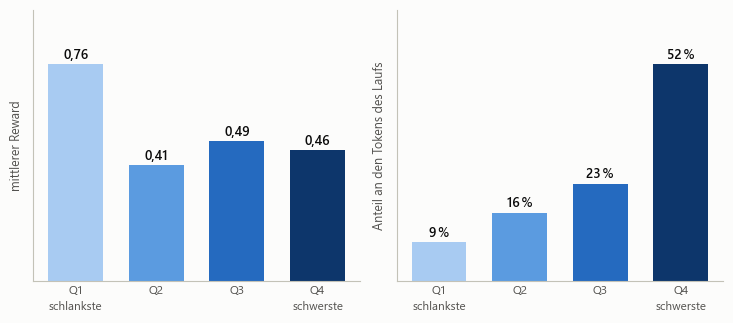

              mean_reward    tokens   n  share
quartile                                      
Q1\nleanest         0.765  16875045  26  0.092
Q2                  0.407  29667883  26  0.161
Q3                  0.493  42593238  26  0.231
Q4\nheaviest        0.460  95073121  26  0.516

            trials  median_tok  mean_reward
difficulty                                 
Easy            26    758403.0       0.6253
Medium          46   1344737.5       0.5359
Hard            32   2313682.0       0.4477

Hard against Easy: median tokens x3.1, mean reward x0.72

tokens over the whole run
  input     : 176.9M  (80.5% served from cache)
  output    : 7.32M
  reasoning : 4.96M  (68% of output)
  total     : 184.2M tokens


In [7]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.token_quartiles(df), "token-quartiles")
plt.show()

print(ja.token_quartile_table(df).round(3).to_string())
print()

levels = ja.by_difficulty(df)
print(levels.round(4).to_string())
print()
# Stated as a ratio in a fixed direction rather than as "more" or "less": not
# every arm consumes more on the harder half, and one of them consumes less.
tok = levels.median_tok["Hard"] / levels.median_tok["Easy"]
reward = levels.mean_reward["Hard"] / levels.mean_reward["Easy"]
print(f"Hard against Easy: median tokens x{tok:.1f}, mean reward x{reward:.2f}")

print()
print("tokens over the whole run")
print(f"  input     : {df.in_tok.sum() / 1e6:.1f}M"
      f"  ({df.cache_tok.sum() / df.in_tok.sum():.1%} served from cache)")
print(f"  output    : {df.out_tok.sum() / 1e6:.2f}M")
print(f"  reasoning : {df.reasoning_tok.sum() / 1e6:.2f}M"
      f"  ({df.reasoning_tok.sum() / df.out_tok.sum():.0%} of output)")
print(f"  total     : {ja.fmt_tokens(df.total_tok.sum())} tokens")

Aggregating the same consumption by what it produced gives the figure worth quoting.

wrote docs\figures\selfcollab-tokens-by-outcome.png


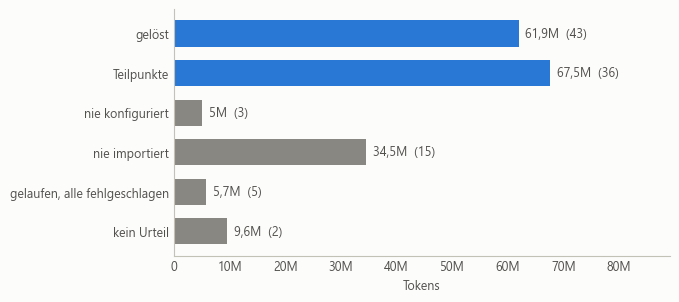

In [8]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.tokens_by_outcome(df), "tokens-by-outcome")
plt.show()

## 7. Why each zero was a zero

"Scored nothing" is not a diagnosis. The verifier writes a full pytest report for every
trial, and that report names the exception that stopped the run — so each zero can be
given the technical reason it earned, read from its own output rather than assigned by
hand. `ja.classify_zero` does this identically for every arm.

Each zero gets a **stage** and a **cause**. The stage is how far the pipeline got:

| Stage | Meaning |
| --- | --- |
| `never configured` | pytest refused to start — unparsable `pyproject.toml`, a config option needing a plugin that is not installed, an incompatible plugin, or no tests collected at all |
| `never imported` | pytest started, and the generated code failed to import |
| `ran, all failed` | the code imported, the tests executed, and every one of them failed |
| `no verdict` | the tester never produced a real judgement — a harness fault, not a finding about the code |

The cause is the exception itself. Two of them are refined further, because the
exception name on its own hides the mistake:

- **`ModuleNotFoundError`** is four different errors. *Own code, wrong layout* — the
  file is in the workspace, but not importable under the name its own code uses.
  *A file it never wrote* — the package is there, the module it imports is not.
  *Uninstalled dependency* — a third-party library the agent assumed would be present.
  *Project built one level too deep* — the whole project sits inside a single
  sub-directory of the workspace. Which one is decided by looking the missing name up
  against everything the agent actually wrote, as a dotted path resolved against both
  import roots and, failing that, against a nested project root.
- **`ImportError`** is three more: a *circular import*; a name *missing from its own
  module*; and a name *gone from an installed module*, which means the code was written
  against an API the installed version does not have.

Where one report holds several exceptions, the cause is the one raised most often — the
error blocking most of the suite, not whichever pytest printed first.

wrote docs\figures\selfcollab-zero-causes.png


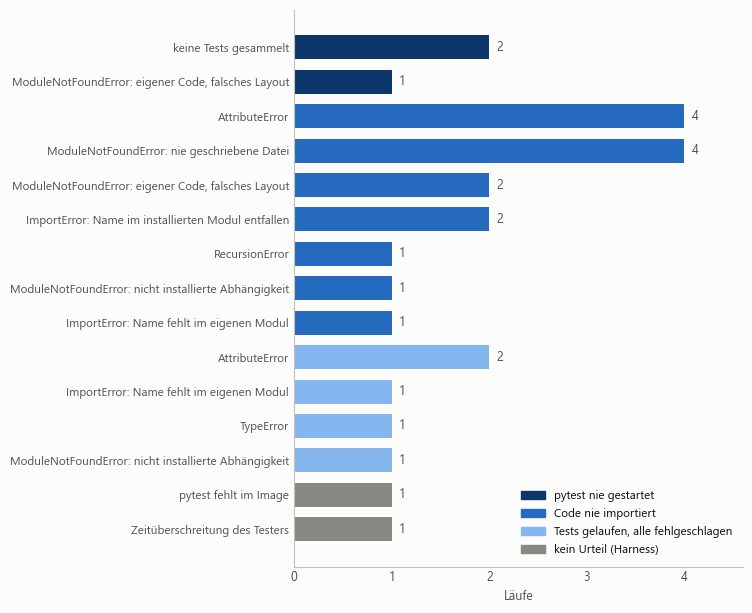

fault_stage
never configured     3
never imported      15
ran, all failed      5
no verdict           2


In [9]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.zero_causes(df), "zero-causes")
plt.show()

zeros = df[df.scored & (df.reward == 0)]
print(zeros.fault_stage.value_counts().reindex(ja.STAGES).fillna(0).astype(int).to_string())

The task behind each row is worth having to hand when reading the figure, so the full
list is printed below, with the loop's own verdict beside each one.

In [10]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)
zeros = df[df.scored & (df.reward == 0)]

table = (zeros[["task", "difficulty", "fault_stage", "fault_cause",
                "rounds", "self_test_passed"]]
         .sort_values(["fault_stage", "fault_cause", "task"])
         .reset_index(drop=True))
with pd.option_context("display.max_rows", None, "display.width", 210,
                       "display.max_colwidth", 44):
    print(table.to_string())

               task difficulty       fault_stage                                      fault_cause  rounds  self_test_passed
0            pylama     Medium  never configured      ModuleNotFoundError: own code, wrong layout       3             False
1              tqdm       Hard  never configured                          no tests were collected       3             False
2        voluptuous     Medium  never configured                          no tests were collected       3             False
3             funcy     Medium    never imported                                   AttributeError       3             False
4           justext       Easy    never imported                                   AttributeError       2              True
5          tenacity     Medium    never imported                                   AttributeError       3             False
6            tinydb     Medium    never imported                                   AttributeError       3             False
7       

## 8. Two checks on the numbers above

**The reward is what it claims to be.** Reward arrives as a single float in
`result.json`, computed inside the container by a tester this notebook never sees. It
should be the fraction of hidden tests that passed, and pytest's own summary line —
parsed independently, out of a different file — agrees with it closely. The residual
gap is that pytest counts a collection error as one unit where the tester counts the
tests it would have contained.

**Every zero was classified, and none was left over.** A zero the classifier could not
read would be filed as `unclassified`, and the count of those is printed below, so that
a silent gap in the taxonomy cannot pass as a clean result.

In [11]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)

ran = df[df.scored & df.pt_ran].copy()
units = (ran.pt_passed + ran.pt_failed + ran.pt_error).replace(0, pd.NA)
ran["pytest_fraction"] = ran.pt_passed / units
agree = ran.dropna(subset=["pytest_fraction"])

print("reward against pytest's own pass fraction")
print(f"  trials compared : {len(agree)} of {int(df.scored.sum())} scored"
      f" ({int(df.scored.sum()) - len(ran)} excluded, pytest never reached a summary)")
print(f"  correlation     : r = {agree.reward.corr(agree.pytest_fraction):.3f}")
print(f"  median gap      : {(agree.reward - agree.pytest_fraction).abs().median():.3f}")
print()

zeros = df[df.scored & (df.reward == 0)]
print(f"unclassified zeros: {int((zeros.fault_cause == 'unclassified').sum())} of {len(zeros)}")
print()
print("how the run stopped, and what each way scored")
print(df.groupby("ending").agg(
    trials=("reward", "size"), mean_reward=("reward", "mean"),
    zeros=("reward", lambda s: int((s == 0).sum()))).round(3).to_string())

reward against pytest's own pass fraction
  trials compared : 89 of 104 scored (13 excluded, pytest never reached a summary)
  correlation     : r = 0.945
  median gap      : 0.000

unclassified zeros: 0 of 25

how the run stopped, and what each way scored
                                       trials  mean_reward  zeros
ending                                                           
passed its own tests at round 1             5        0.963      0
passed its own tests at round 2            10        0.735      1
used every round, never self-verified      89        0.484     24


## What this run says

- **The median trial scores well.** Mean reward 0.53, median 0.63, with a large
  solved-outright group rather than a body of partial credit. The distribution has two
  ends: a substantial block of near-perfect reproductions and a smaller block of zeros,
  with less in between than either of the other arms.
- **Difficulty still dominates.** Easy to Hard is a steep drop, so a comparison run on a
  difficulty-skewed subset will read very differently from one run on the full
  benchmark. That is the case for the balanced subset selected in
  `nl2repobench-subset-selection.ipynb`.
- **The method's own tester gives an asymmetric signal, and rarely gives one at all.**
  A pass is strong evidence — those trials average 0.81 and only one scored zero — but
  only 15 of 104 ever got there. A non-pass says much less: 34 of the 89 that never
  satisfied their own tester were solved outright anyway.
- **The last edit is never checked.** The Tester runs between Coder rounds and not after
  the final one, so in 89 of 104 trials the code the external verifier graded had not
  been run by anything since the Coder last touched it. Adding one more Tester pass at
  the end spends one round of its budget and would at minimum tell the reader which runs
  the method itself believed in.
- **The binding budget is steps, not rounds.** Nine coder rounds in ten used all 15
  steps they were allowed, and every trial had at least one such round. Raising
  `coder_steps` is a more direct lever than raising `max_rounds`.
- **Most zeros are mechanical, not conceptual.** The largest group of zeros is code that
  never imported. Only a minority are runs where the tests executed and the answers were
  wrong.